In [17]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
from rasterio.features import shapes
import rasterio
from shapely.geometry import shape

In [18]:
basins_eu_me = gpd.read_file("../data/hybas_eu_lev01-06_v1c/hybas_eu_lev04_v1c.shp")
rivers_eu = gpd.read_file("../data/HydroRIVERS_v10_eu_shp/HydroRIVERS_v10_eu.shp")
countries = gpd.read_file("../data/world-administrative-boundaries/world-administrative-boundaries.shp")
mines = gpd.read_file("../data/mine_polygons/74548_projected polygons.shp")
flo_IPB = xr.open_dataset("../data/flo_IPB_last_date.nc")


In [19]:
mask_strahler_five = rivers_eu["ORD_STRA"] >= 5
rivers_eu_five = rivers_eu[mask_strahler_five]

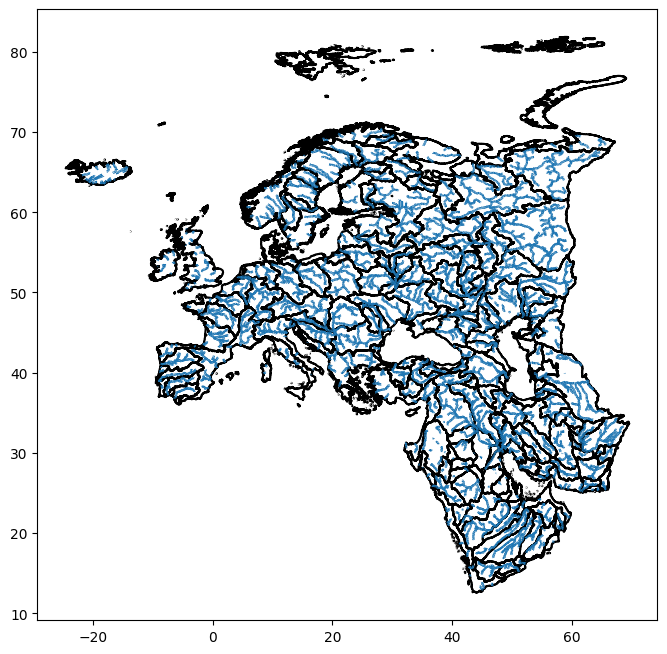

In [20]:
ax = basins_eu_me.boundary.plot(edgecolor = "k", figsize= (8, 8))
rivers_eu_five.plot(ax = ax);

In [21]:
IPB = basins_eu_me.iloc[45:53]
spain_mask  = countries["English_Nam"] == "Spain" 
portugal_mask = countries["English_Nam"] == "Portugal"
mask_iberia = spain_mask | portugal_mask
iberia = countries[mask_iberia]

In [22]:
rivers_in_IPB = gpd.sjoin(rivers_eu, IPB, predicate='intersects', how='inner')

In [28]:
print(flo_IPB["qav"].values.max())
print(flo_IPB["qav"].values.min())

nan
nan


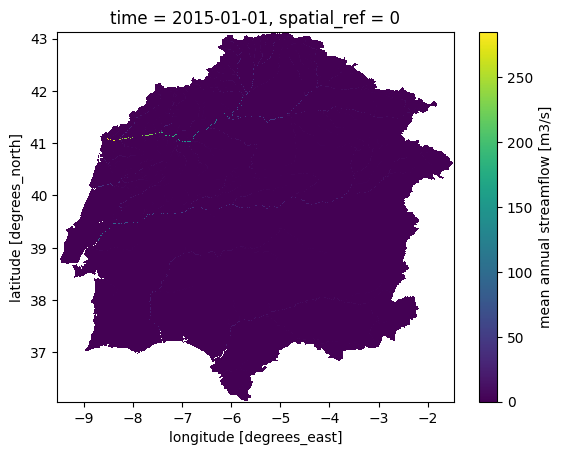

In [30]:
flo_IPB["qav"].plot()

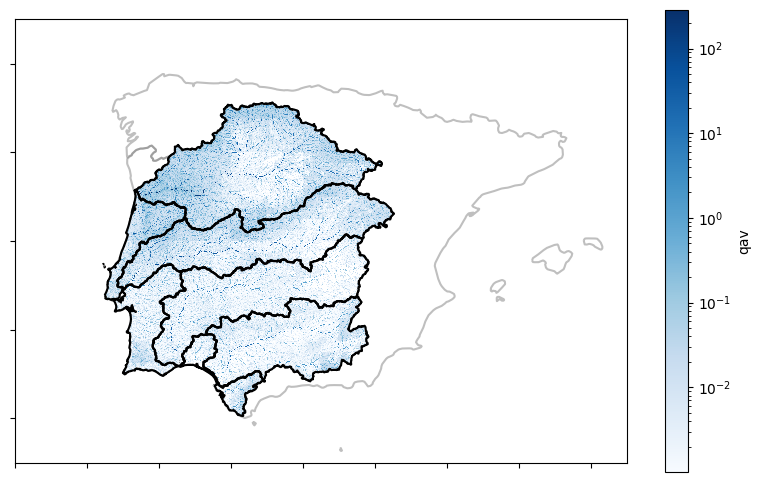

In [39]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize = (8, 8))

IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)

flo_IPB_plot = flo_IPB["qav"].where(flo_IPB["qav"] > 0)
norm = mcolors.LogNorm(vmin=flo_IPB_plot.min(), vmax=flo_IPB_plot.max())
flo_IPB_plot.plot(ax = ax, cmap = "Blues",  norm = norm, cbar_kwargs={'shrink': 0.6, 'label': 'qav'})
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_flo1k.png", dpi = 200)
plt.show()
plt.close()

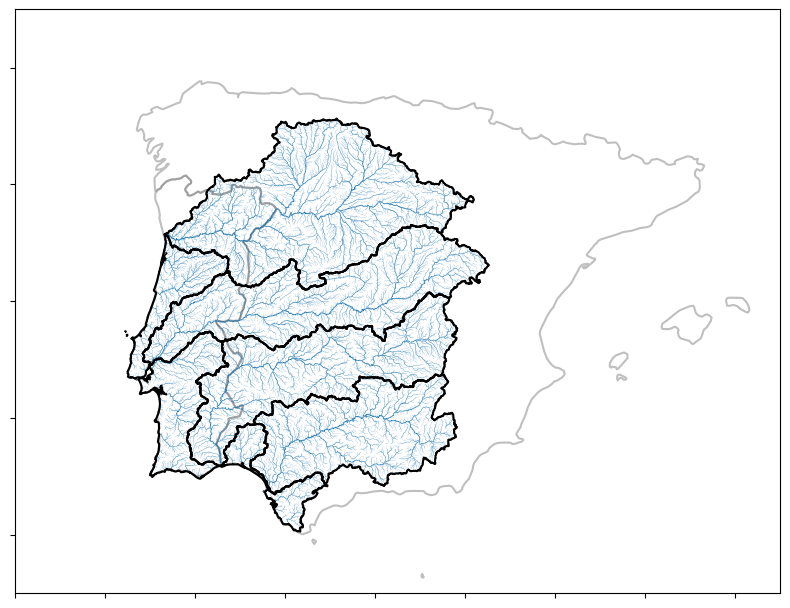

In [ ]:
fig, ax = plt.subplots(figsize = (8, 8))
sizes = rivers_in_IPB["ORD_STRA"].fillna(1).astype(float) * 0.1
IPB.boundary.plot(edgecolor = "k", zorder = 10, ax = ax)
iberia.boundary.plot(edgecolor = "grey", zorder = 1, ax = ax, alpha = 0.5)
rivers_in_IPB.plot(ax = ax,linewidth=sizes)
ax.set_xlim(-12, 5)
ax.set_ylim(35, 45)
ax.set_xticklabels("")
ax.set_yticklabels("")
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title("")
plt.tight_layout()
fig.savefig("test_hydrorivers.png", dpi = 200)
plt.show()
plt.close()

In [ ]:
mines.to_crs(4326, inplace = True)
IPB_mines = gpd.sjoin(mines, IPB, predicate='intersects', how='inner')

In [ ]:
IPB_mines.explore()